<a href="https://colab.research.google.com/github/narsimha1603/Major-Project/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from mlxtend.frequent_patterns import apriori, association_rules
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
print('Deprecation warnings have been suppressed.')

Deprecation warnings have been suppressed.


In [ ]:
data = pd.read_csv("/content/dengue_dataset_5000_cases.csv")
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data = data.asfreq('D')
print("Dataset Loaded Successfully with Daily Frequency")
print(data.head())

Dataset Loaded Successfully with Daily Frequency
            Temperature (°C)  Rainfall (mm)  Humidity (%)  Dengue_Cases
Date                                                                   
2010-01-01             25.44         106.28         58.92            13
2010-01-02             25.55         102.83         61.57            14
2010-01-03             25.12          95.48         62.61            14
2010-01-04             25.01         134.35         55.65            19
2010-01-05             25.61          46.88         64.08            13


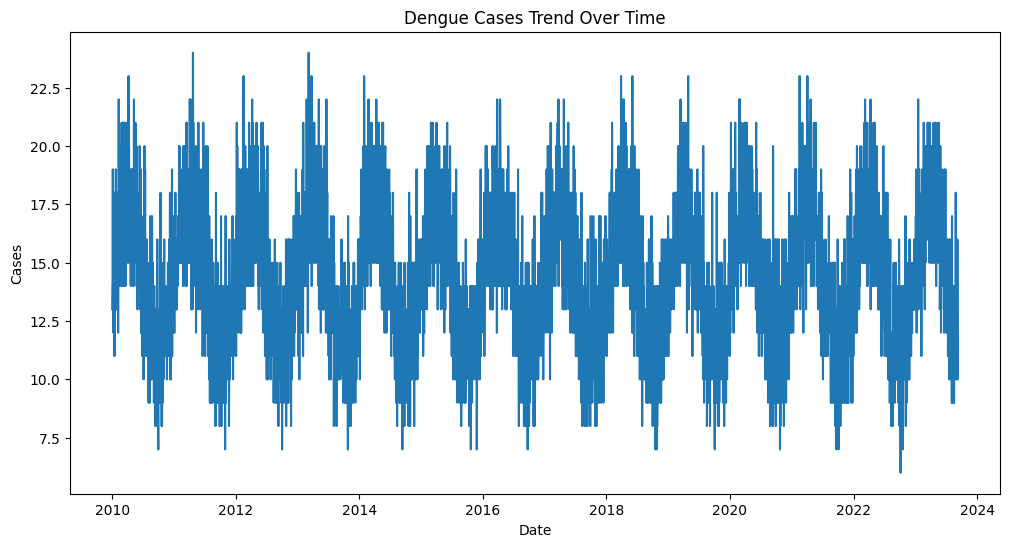

In [ ]:
#DATA UNDERSTANDING
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Dengue_Cases'])
plt.title("Dengue Cases Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

In [ ]:
#DATA PREPROCESSING Handle Missing Values
data = data.ffill()

In [ ]:
#Normalize Weather Variables
scaler = MinMaxScaler()
data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']] = scaler.fit_transform(
    data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']])

In [ ]:
#Stationarity Test (ADF)
result = adfuller(data['Dengue_Cases'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])
if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Not Stationary")

ADF Statistic: -4.128511030014541
p-value: 0.0008686016565226949
Series is Stationary


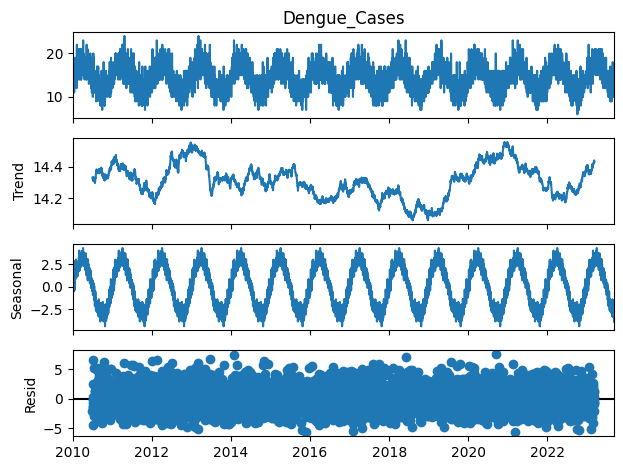

In [ ]:
#TIME SERIES DECOMPOSITION
decomposition = seasonal_decompose(data['Dengue_Cases'], model='additive', period=365)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid
decomposition.plot()
plt.show()

In [ ]:
#ASSOCIATION RULE MINING (ARM MODEL)
arm_data = data.copy()
arm_data['High_Temp'] = arm_data['Temperature (°C)'] > arm_data['Temperature (°C)'].mean()
arm_data['High_Rain'] = arm_data['Rainfall (mm)'] > arm_data['Rainfall (mm)'].mean()
arm_data['High_Humidity'] = arm_data['Humidity (%)'] > arm_data['Humidity (%)'].mean()
arm_data['High_Cases'] = arm_data['Dengue_Cases'] > arm_data['Dengue_Cases'].mean()
arm_df = arm_data[['High_Temp','High_Rain','High_Humidity','High_Cases']]
frequent = apriori(arm_df, min_support=0.3, use_colnames=True)
rules = association_rules(frequent, metric="confidence", min_threshold=0.6)
print("\nAssociation Rules")
print(rules[['antecedents','consequents','support','confidence']])


Association Rules
                               antecedents  \
0                              (High_Temp)   
1                              (High_Rain)   
2                              (High_Temp)   
3                          (High_Humidity)   
4                              (High_Temp)   
5                             (High_Cases)   
6                              (High_Rain)   
7                          (High_Humidity)   
8                              (High_Rain)   
9                             (High_Cases)   
10                         (High_Humidity)   
11                            (High_Cases)   
12              (High_Temp, High_Humidity)   
13                  (High_Temp, High_Rain)   
14              (High_Rain, High_Humidity)   
15                             (High_Temp)   
16                         (High_Humidity)   
17                             (High_Rain)   
18                 (High_Temp, High_Cases)   
19                 (High_Rain, High_Cases)   
20             

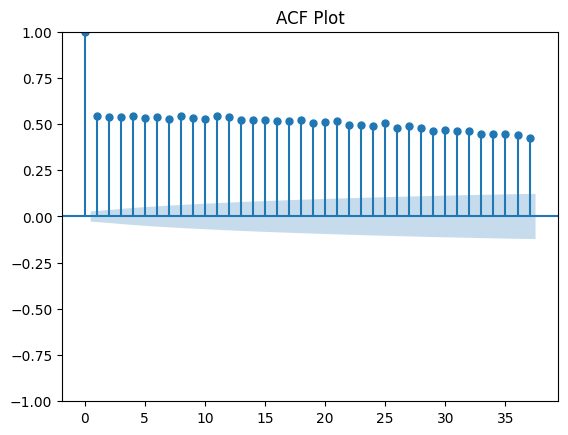

In [ ]:
#PARAMETER ESTIMATION (ACF & PACF)ACF Graph
plot_acf(data['Dengue_Cases'])
plt.title("ACF Plot")
plt.show()

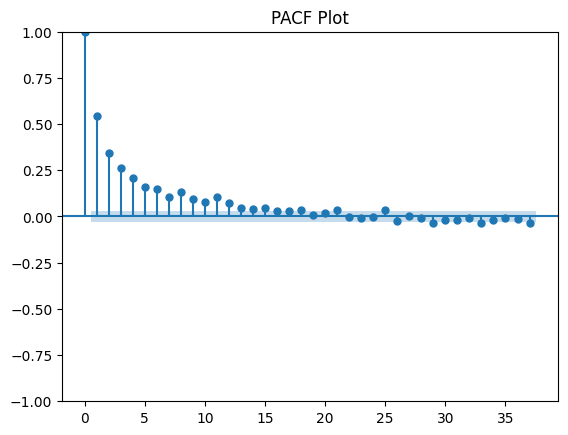

In [ ]:
#PACF Graph
plot_pacf(data['Dengue_Cases'])
plt.title("PACF Plot")
plt.show()

In [6]:
#ARIMA MODEL
ts = data['Dengue_Cases']
p, d, q = 1, 1, 1
arima_model = ARIMA(ts, order=(p,d,q))
arima_fit = arima_model.fit()
print(f"ARIMA Model (order={p},{d},{q}) Built Successfully")

ARIMA Model (order=1,1,1) Built Successfully


In [7]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler

# 1. Load and Preprocess Data
try:
    data = pd.read_csv('/content/dengue_dataset_5000_cases.csv')
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)
    data = data.asfreq('D').ffill()

    # Normalize weather variables (as done in previous steps)
    scaler = MinMaxScaler()
    data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']] = scaler.fit_transform(
        data[['Temperature (°C)','Rainfall (mm)','Humidity (%)']])

    # 2. Train ARIMA Model
    ts = data['Dengue_Cases']
    p, d, q = 1, 1, 1
    arima_model = ARIMA(ts, order=(p,d,q))
    arima_fit = arima_model.fit()
    print(f'Data Loaded and ARIMA Model (order={p},{d},{q}) Trained Successfully')

    # 3. Generate Forecast
    forecast_30_days = arima_fit.forecast(steps=30)
    future_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
    forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted_Cases': forecast_30_days.values})

    print('\n--- Predicted Dengue Cases for the Next Week ---')
    display(forecast_df.head(7))

    print('\n--- Predicted Dengue Cases for the Next Month ---')
    display(forecast_df)

except FileNotFoundError:
    print('Error: CSV file not found at /content/dengue_dataset_5000_cases.csv')
except Exception as e:
    print(f'An error occurred: {e}')

Data Loaded and ARIMA Model (order=1,1,1) Trained Successfully

--- Predicted Dengue Cases for the Next Week ---


,Date,Predicted_Cases
0,2023-09-10,12.364381
1,2023-09-11,12.355656
2,2023-09-12,12.355865
3,2023-09-13,12.355860
4,2023-09-14,12.355860
5,2023-09-15,12.355860
6,2023-09-16,12.355860



--- Predicted Dengue Cases for the Next Month ---


,Date,Predicted_Cases
0,2023-09-10,12.364381
1,2023-09-11,12.355656
2,2023-09-12,12.355865
3,2023-09-13,12.355860
4,2023-09-14,12.355860
5,2023-09-15,12.355860
6,2023-09-16,12.355860
7,2023-09-17,12.355860
8,2023-09-18,12.355860
9,2023-09-19,12.355860


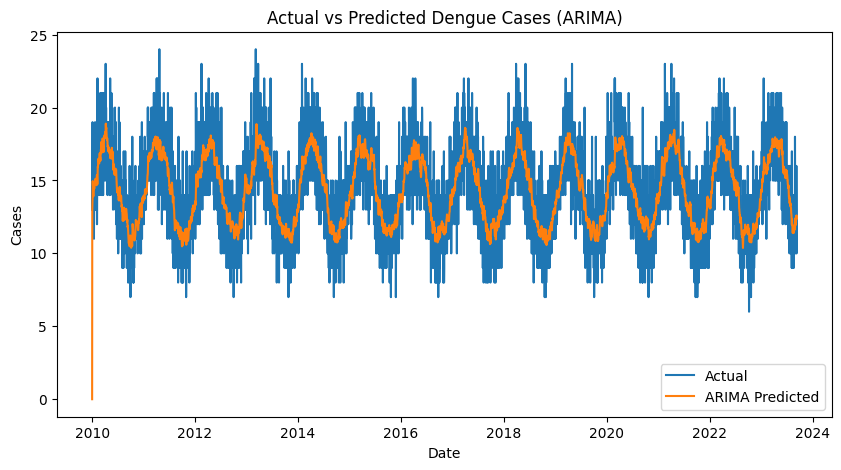

In [ ]:
#ARIMA ACTUAL VS PREDICTED COMPARISON
predicted = arima_fit.predict(start=data.index[0], end=data.index[-1])
plt.figure(figsize=(10,5))
plt.plot(data.index, data['Dengue_Cases'], label="Actual")
plt.plot(data.index, predicted, label="ARIMA Predicted")
plt.legend()
plt.title("Actual vs Predicted Dengue Cases (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.show()

In [ ]:
#MODEL EVALUATION
rmse = np.sqrt(mean_squared_error(data['Dengue_Cases'], predicted))
mae = mean_absolute_error(data['Dengue_Cases'], predicted)
print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2.1456684189942234
MAE: 1.7118821443557357


In [ ]:
num_days = len(data)
start_date = data.index.min()
end_date = data.index.max()
print(f'The dataset contains {num_days} days.')
print(f'Date Range: {start_date.date()} to {end_date.date()}')

The dataset contains 5000 days.
Date Range: 2010-01-01 to 2023-09-09


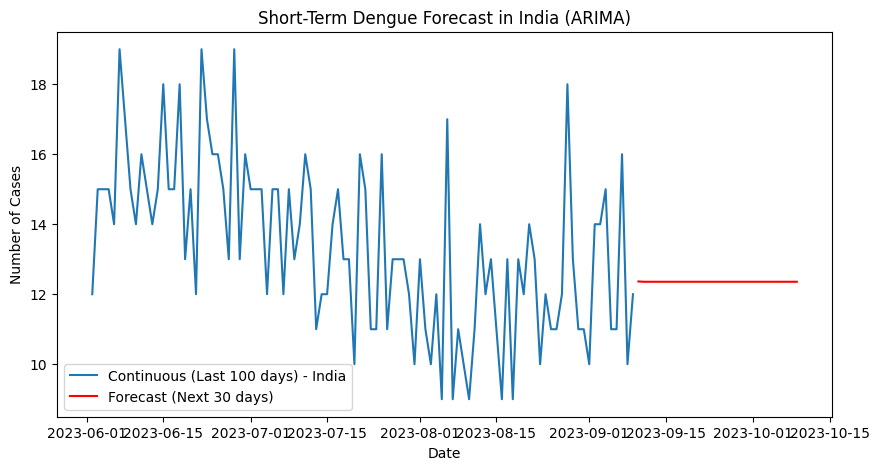

In [ ]:
#ARIMA FORECAST GRAPH
steps = 30
forecast = arima_fit.forecast(steps=steps)
future_index = pd.date_range(start=data.index[-1], periods=steps+1, freq='D')[1:]

plt.figure(figsize=(10,5))
plt.plot(data.index[-100:], data['Dengue_Cases'].tail(100), label="Continuous (Last 100 days) - India")
plt.plot(future_index, forecast, label="Forecast (Next 30 days)", color='red')
plt.legend()
plt.title("Short-Term Dengue Forecast in India (ARIMA)")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.show()

In [8]:
import pandas as pd

try:
    # Get the 30-day forecast from the fitted ARIMA model
    forecast_30_days = arima_fit.forecast(steps=30)
    future_dates = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
    forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted_Cases': forecast_30_days.values})

    # 1. Next Week (Next 7 Days)
    next_week = forecast_df.head(7)
    print("--- Predicted Dengue Cases for the Next Week ---")
    display(next_week)
    print(f"Total predicted cases for next week: {round(next_week['Predicted_Cases'].sum())}")

    # 2. Next Month (Next 30 Days)
    print("\n--- Predicted Dengue Cases for the Next Month ---")
    display(forecast_df)
    print(f"Total predicted cases for next month: {round(forecast_df['Predicted_Cases'].sum())}")
except NameError:
    print("Error: 'arima_fit' not found. Please run the ARIMA MODEL cell (ZiapEgausT4o) first to train the model.")

--- Predicted Dengue Cases for the Next Week ---


,Date,Predicted_Cases
0,2023-09-10,12.364381
1,2023-09-11,12.355656
2,2023-09-12,12.355865
3,2023-09-13,12.355860
4,2023-09-14,12.355860
5,2023-09-15,12.355860
6,2023-09-16,12.355860


Total predicted cases for next week: 86

--- Predicted Dengue Cases for the Next Month ---


,Date,Predicted_Cases
0,2023-09-10,12.364381
1,2023-09-11,12.355656
2,2023-09-12,12.355865
3,2023-09-13,12.355860
4,2023-09-14,12.355860
5,2023-09-15,12.355860
6,2023-09-16,12.355860
7,2023-09-17,12.355860
8,2023-09-18,12.355860
9,2023-09-19,12.355860


Total predicted cases for next month: 371


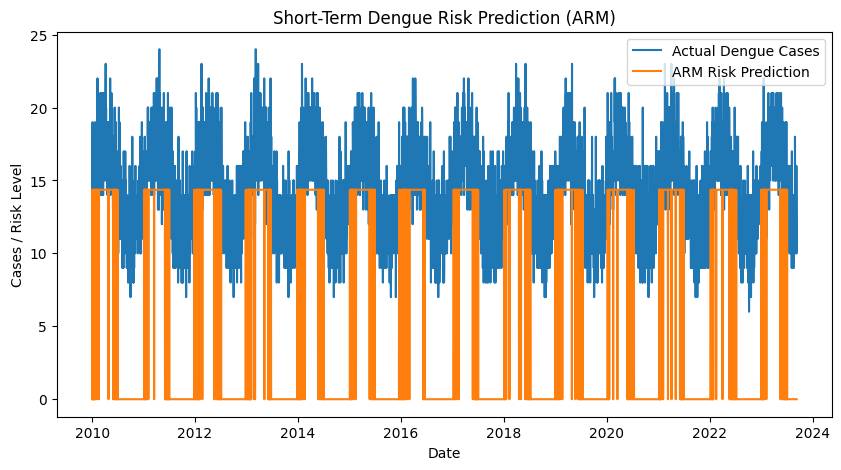

In [ ]:
#ARM SHORT-TERM RISK PREDICTION GRAPH
risk_prediction = arm_data['High_Temp'] & arm_data['High_Rain'] & arm_data['High_Humidity']
risk_prediction = risk_prediction.astype(int)
plt.figure(figsize=(10,5))
plt.plot(data.index, data['Dengue_Cases'], label="Actual Dengue Cases")
plt.plot(data.index,
         risk_prediction * data['Dengue_Cases'].mean(),
         label="ARM Risk Prediction")
plt.legend()
plt.title("Short-Term Dengue Risk Prediction (ARM)")
plt.xlabel("Date")
plt.ylabel("Cases / Risk Level")
plt.show()